# Basic Salary Prediction Using Random Forest

This notebook builds a basic salary prediction model using the `Employee.csv` dataset. It keeps the workflow simple: load data, prepare features, train a Random Forest model, and evaluate the results.

In [26]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load Dataset

In [27]:
DATA_PATH = Path('Employee.csv')
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Dataset Overview

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [29]:
df.describe(include='all').transpose().head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


## 3. Missing Values Analysis

In [30]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

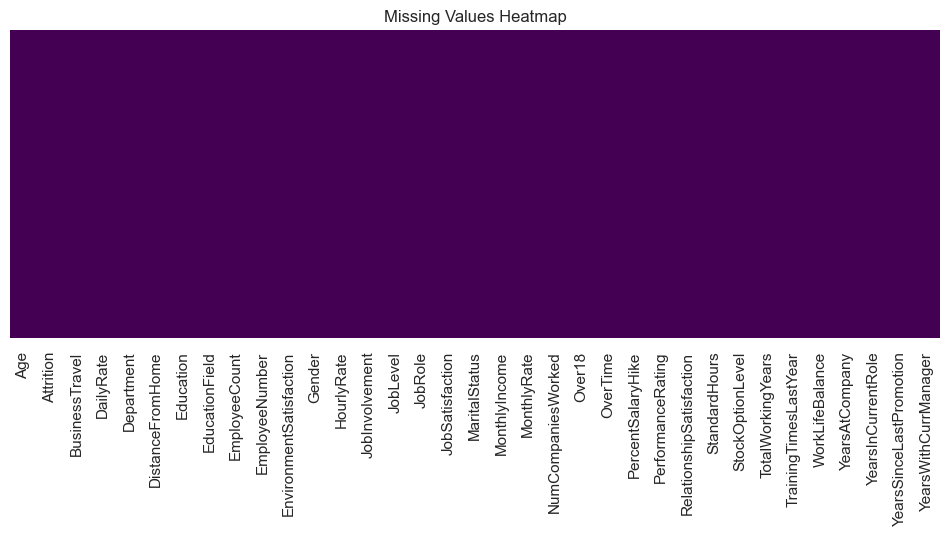

In [31]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## 4. Exploratory Data Analysis

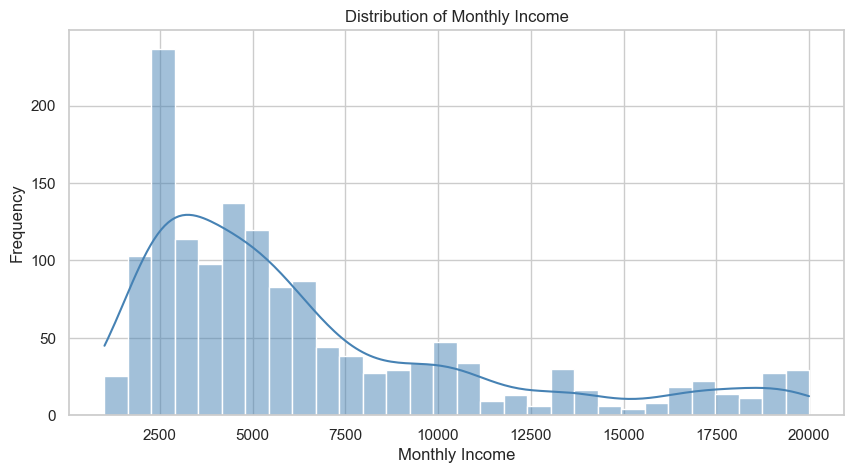

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()

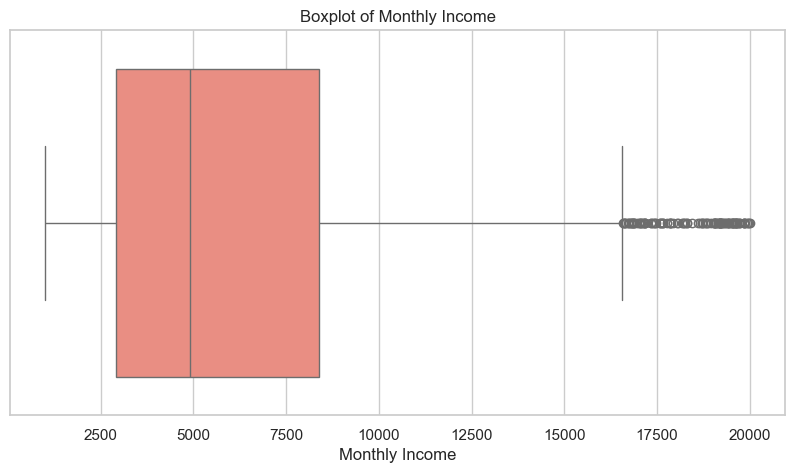

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['MonthlyIncome'], color='salmon')
plt.title('Boxplot of Monthly Income')
plt.xlabel('Monthly Income')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12588\832847334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='JobRole', y='MonthlyIncome', order=job_order, estimator=np.mean, palette='Set2')


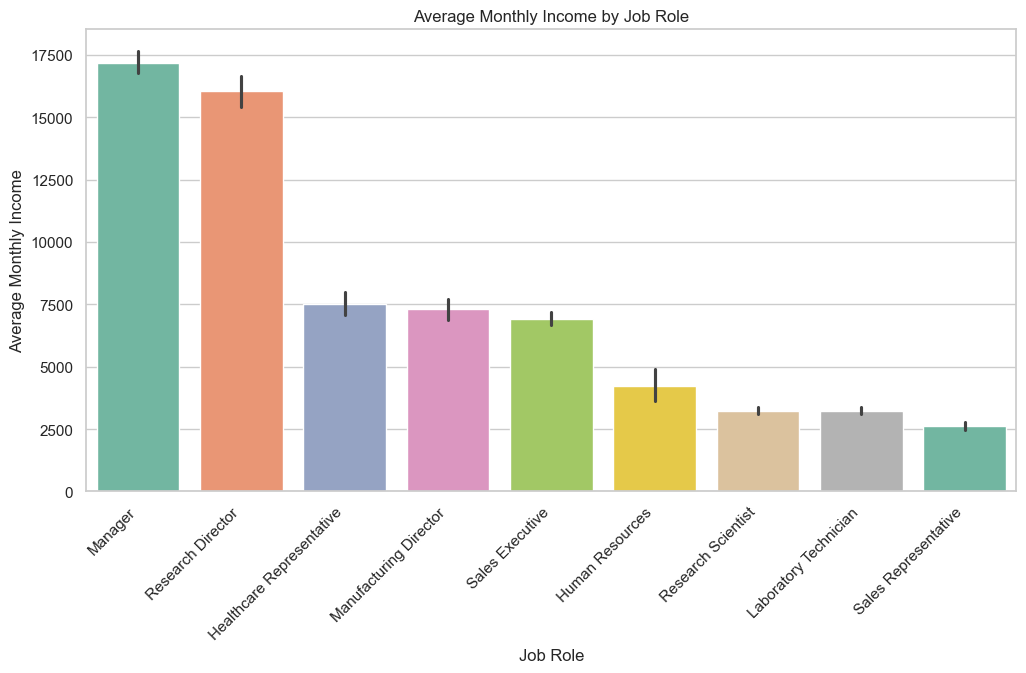

In [34]:
plt.figure(figsize=(12, 6))
job_order = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='JobRole', y='MonthlyIncome', order=job_order, estimator=np.mean, palette='Set2')
plt.title('Average Monthly Income by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45, ha='right')
plt.show()

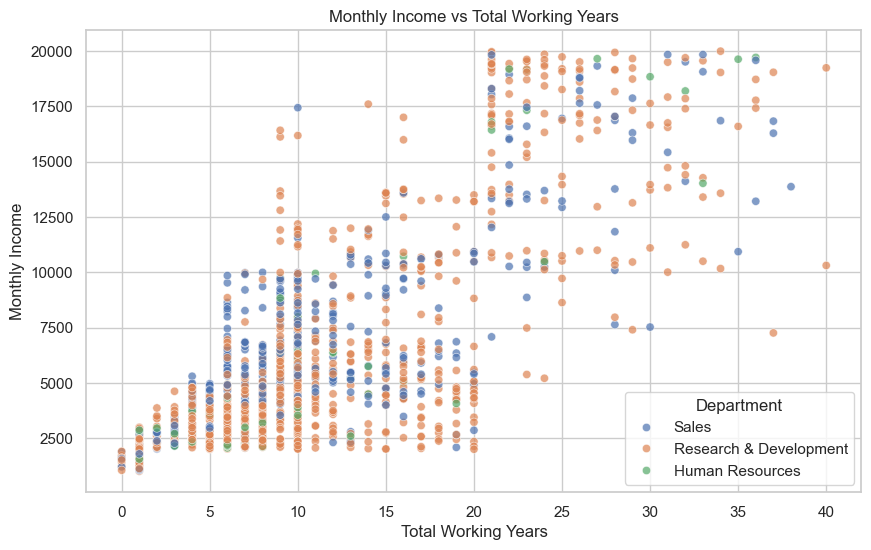

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='Department', alpha=0.7)
plt.title('Monthly Income vs Total Working Years')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.show()

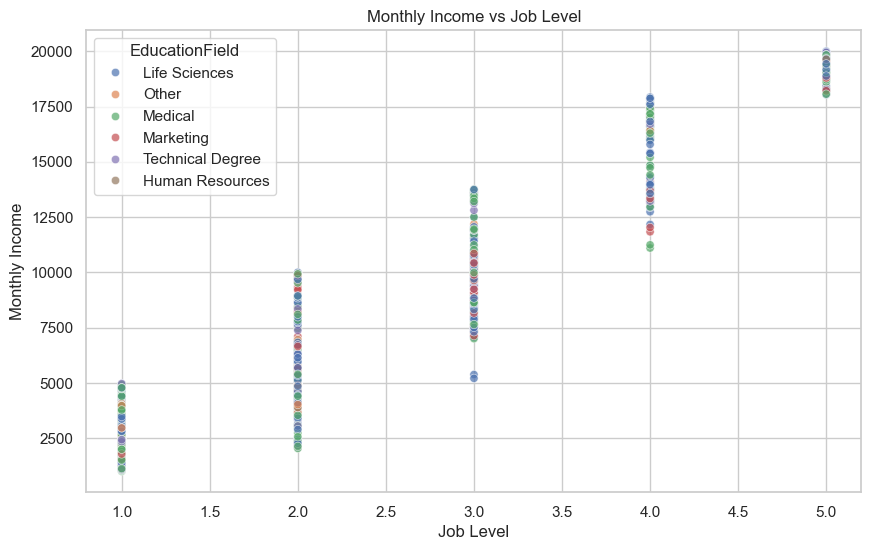

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='JobLevel', y='MonthlyIncome', hue='EducationField', alpha=0.7)
plt.title('Monthly Income vs Job Level')
plt.xlabel('Job Level')
plt.ylabel('Monthly Income')
plt.show()

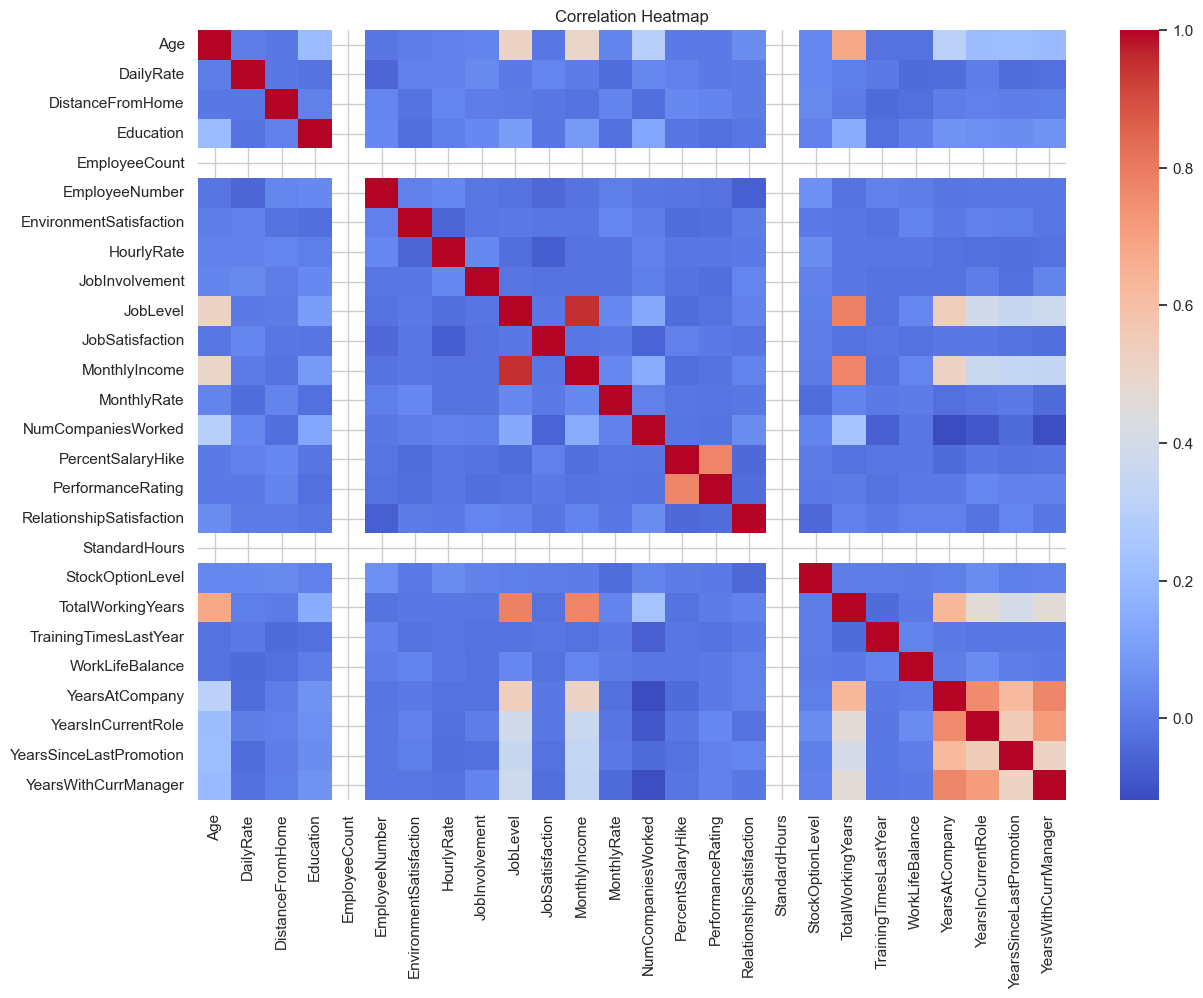

In [37]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12588\1368846235.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='mako')


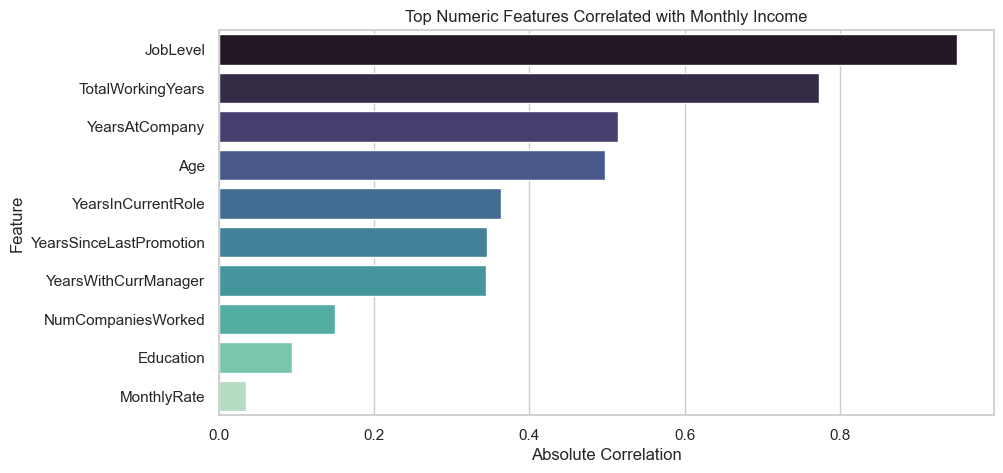

In [38]:
top_corr = corr['MonthlyIncome'].drop('MonthlyIncome').abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='mako')
plt.title('Top Numeric Features Correlated with Monthly Income')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.show()

## 5. Prepare Features and Target

In [39]:
target_column = 'MonthlyIncome'
drop_columns = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

X = df.drop(columns=[target_column] + drop_columns)
y = df[target_column]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print('Number of numeric features:', len(numeric_features))
print('Number of categorical features:', len(categorical_features))
print('Target column:', target_column)

Number of numeric features: 22
Number of categorical features: 8
Target column: MonthlyIncome


## 6. Simple Data Preparation

In [40]:
X_simple = X.copy()

for col in numeric_features:
    X_simple[col] = X_simple[col].fillna(X_simple[col].median())

for col in categorical_features:
    X_simple[col] = X_simple[col].fillna(X_simple[col].mode()[0])

X_simple = pd.get_dummies(X_simple, drop_first=True)
X_simple.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,19479,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,24907,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2396,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,23159,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,16632,...,True,False,False,False,False,False,False,True,False,False


## 7. Train/Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (1176, 44)
Testing shape: (294, 44)


## 8. Train Random Forest Model

In [42]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Random Forest model trained successfully.')

Random Forest model trained successfully.


## 9. Model Evaluation

In [43]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE: 821.27
RMSE: 1104.04
R2 Score: 0.9442


In [44]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})
results_df.head()

,Actual,Predicted
0,8463,6564.23
1,4450,4063.82
2,1555,2170.70
3,9724,10206.38
4,5914,4034.37


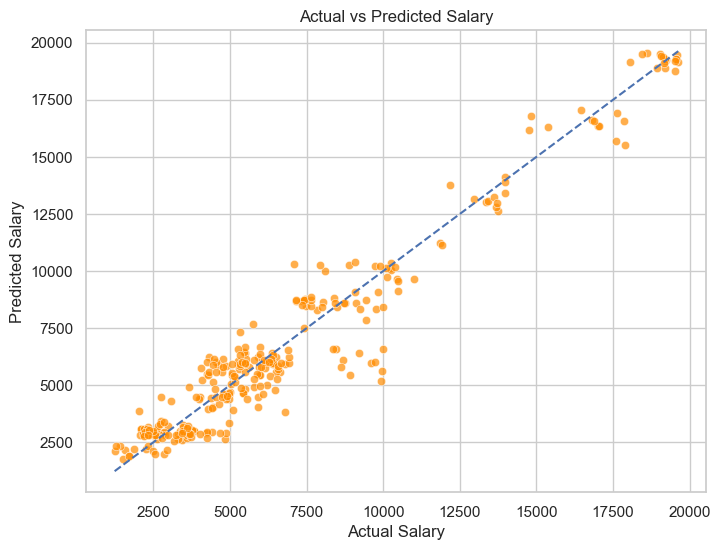

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x='Actual', y='Predicted', color='darkorange', alpha=0.7)
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()], [results_df['Actual'].min(), results_df['Actual'].max()], 'b--')
plt.title('Actual vs Predicted Salary')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.show()

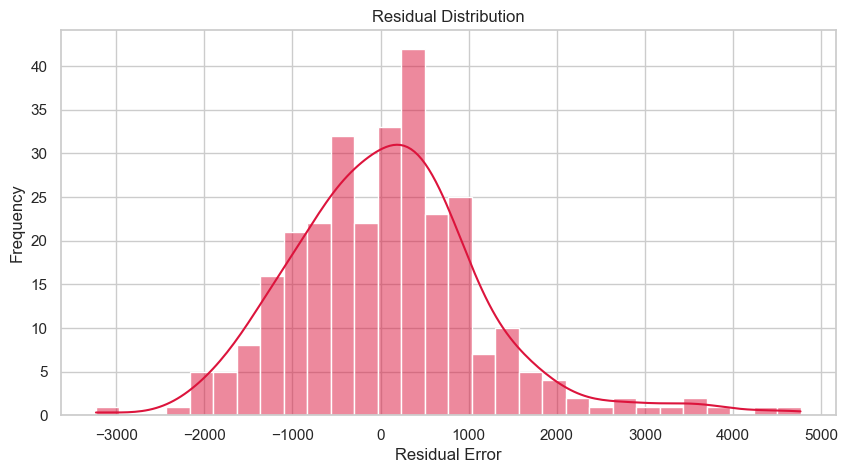

In [46]:
residuals = y_test.values - predictions

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color='crimson')
plt.title('Residual Distribution')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.show()

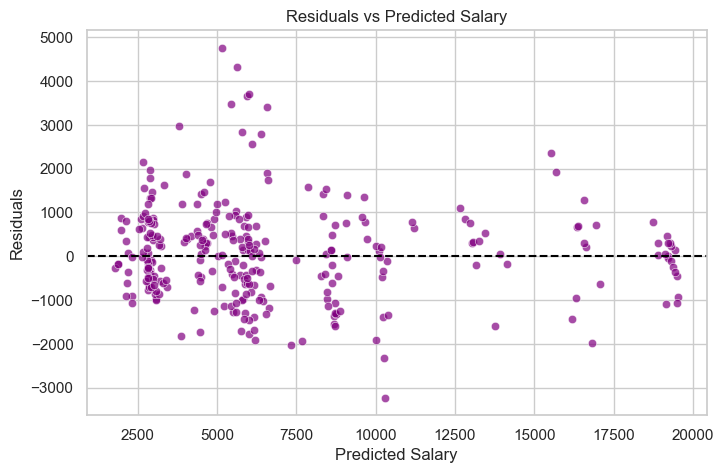

In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=predictions, y=residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted Salary')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.show()

## 10. Feature Importance

In [48]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

importance_df

,Feature,Importance
7,JobLevel,0.927605
37,JobRole_Research Director,0.010629
15,TotalWorkingYears,0.009970
35,JobRole_Manager,0.005570
1,DailyRate,0.004472
9,MonthlyRate,0.004447
34,JobRole_Laboratory Technician,0.003585
5,HourlyRate,0.003302
0,Age,0.002272
2,DistanceFromHome,0.002258


C:\Users\HP\AppData\Local\Temp\ipykernel_12588\2241235668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


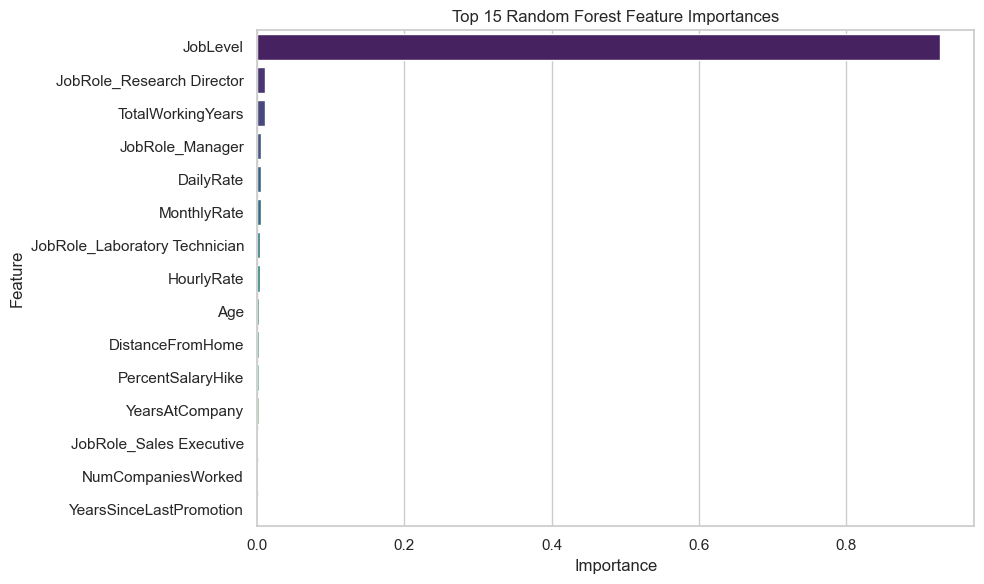

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 11. Sample Prediction

In [50]:
sample_employee = X_test.iloc[[0]]
sample_prediction = model.predict(sample_employee)[0]
actual_salary = y_test.iloc[0]

print(f'Predicted Salary: {sample_prediction:.2f}')
print(f'Actual Salary: {actual_salary:.2f}')
sample_employee

Predicted Salary: 6564.23
Actual Salary: 8463.00


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1041,28,866,5,3,4,84,3,2,1,23490,...,False,False,False,False,False,True,False,False,True,False


## 12. Conclusion

This notebook uses a basic Random Forest regression model for salary prediction. The workflow is short, readable, and suitable for a simple project submission.